In [219]:
#Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [220]:
# Filepath
filepath = '/Users/epalmer/MET4400C_Ins-obs_labs/Labs/lab_3_files/Data_Lab3'

# Important Constants
Rd = 287 # Specific gas constant of dry air
Rv = 461.5 # Specific gas constant of moist air/ water vapor
eps = Rv/Rd # Saturated vapor pressure
Lv = 2.5*10**6 # latent heat of vaporization
cp = 1004 # specific heat of air at constant pressure
C = 1.2 * 10**-3 # Bulk transfer coefficient

In [221]:
# Reading in the Lake Ella Data
data = pd.read_csv(f'{filepath}/Lake_Ella_Data_Collection.csv', header=1)
data

,t,p,Tair1,Tair2,Tair3,Tair4,Tair5,Tair6,Tw1,Tw2,...,Tw5,Tw6,Tsfc1,Tsfc2,U1,U2,U3,U4,U5,U6
0,3/6/2026 11:30 AM,1022.8,25.0,25.5,24.0,25.0,25,24.0,22.0,22.0,...,22,22.0,21.9,24.3,1.3,1.9,1.1,0.4,0.8,1.9
1,3/6/2026 11:33 AM,1022.8,25.0,25.0,25.0,25.5,26,24.0,21.0,21.0,...,22,21.4,21.5,23.5,0.5,2.9,0.6,0.5,1.3,0.5
2,3/6/2026 11:36 AM,1022.8,25.0,24.5,25.0,25.0,25,24.5,21.0,21.0,...,21,22.0,21.5,23.4,1.3,0.6,0.5,0.6,0.0,1.0
3,3/6/2026 11:39 AM,1022.7,25.2,25.0,25.0,25.0,25,24.5,21.0,21.0,...,21,21.2,21.9,23.5,0.9,2.3,1.5,0.4,0.0,1.8
4,3/6/2026 11:42 AM,1022.7,25.0,24.5,25.0,25.0,25,25.0,21.0,21.0,...,21,22.0,22.1,23.6,0.7,1.0,0.6,0.6,0.5,2.0
5,3/6/2026 11:45 AM,1022.7,25.5,25.5,25.0,25.5,25,25.1,21.5,21.5,...,22,22.0,23.0,23.5,0.8,0.9,0.7,0.7,0.7,1.4
6,3/6/2026 11:48 AM,1022.7,25.8,25.0,25.5,25.0,25,24.5,21.0,21.0,...,22,21.9,22.5,23.5,0.4,3.0,0.4,0.4,1.0,1.3
7,3/6/2026 11:51 AM,1022.7,25.5,26.0,26.0,25.5,26,25.0,21.5,21.5,...,22,22.0,21.8,23.3,1.4,0.6,0.6,0.9,0.8,1.4
8,3/6/2026 11:54 AM,1022.6,26.0,24.5,26.0,25.5,26,25.0,21.0,21.0,...,22,22.0,22.4,24.0,1.2,0.6,0.8,0.3,0.6,1.2
9,3/6/2026 11:57 AM,1022.6,26.0,26.0,26.0,26.0,26,25.0,22.5,22.5,...,23,22.0,21.7,25.5,0.0,0.7,0.8,1.2,0.4,0.4


In [222]:
# Get pressure from datafram
p = data['p'] * 10**2 # convert from hPa to Pa

In [223]:
# Get dry bulb temperature data
Tair_cols = [f'Tair{n}' for n in range(1,6+1)] # selecting all the columns of dry bulb measurements
Tair = data[Tair_cols].mean(axis = 1) + 273.15 # Average Temperature of all air measurements in Kelvin

In [224]:
# Get Wet bulb temperature 
Twet_cols = [f'Tw{n}' for n in range(1,6+1)] # Selecting all the columns of wet bulb measurements
Twet = data[Twet_cols].mean(axis=1) + 273.15 # Average Temperature of all wet bulb air measurements in kelvin

In [225]:
Tsfc_cols = ['Tsfc1','Tsfc2'] # Surface temperature in Kelvin
Tsfc = data[Tsfc_cols].mean(axis=1) + 273.15 # Average surface temperature in Kelvin

In [226]:
#Get wind speed data in m s-1
U_cols = [f'U{n}' for n in range(1,6+1)]
U = data[U_cols] #Don't average yet, as we care about the standard deviation of all the wind measurements

In [227]:
# Calculating Saturation Vapor Pressure es(T) using the Clausius-Clapeyron equation
def es(T):
    '''Calculate the Saturation Vapor Pressure using the Clausius-Clapeyron equation
    
    Parameters 
    ----------
    T : K 
    Temperature in Kelvin
    
    Returns
    ----------
    es : Pa 
    Saturation Vapor Pressure in Pascals
    '''
    #Formula es(T) = Aw * exp(-Bw/T)
    Aw = 2.53 * 10**11 # Pa
    Bw = 5420 # K
    es = Aw * np.exp(-Bw/T)

    return es 

In [228]:
# calculating Saturation vapor pressure using function
esw = es(Twet) # Saturation vapor pressure at wet bulb temperature

In [229]:
# Partial Pressure of water vapor
A = 0.00062 # K^-1
e = esw - A *(Tair - Twet) * p # Partial pressure of water vapor in Pa

In [230]:
#Finding specific humidity of air
qair = 0.622 * e/p # Specific humidity in kg/kg
1000*qair

0     15.113584
1     14.385962
2     14.734558
3     14.507522
4     14.703982
5     15.032334
6     14.944104
7     14.994882
8     14.874045
9     16.001340
10    16.044104
11    15.327930
12    14.849929
13    14.674853
14    14.603841
15    14.927052
16    16.285820
17    15.012459
18    14.917981
19    15.215239
20    14.914995
dtype: float64

In [231]:
#Specific humidity at surface 
qsfc = 0.622 * esw/p # Specific humidity at the surface in kg/kg
1000*qsfc

0     16.206230
1     15.774266
2     15.955751
3     15.825126
4     15.957312
5     16.292091
6     16.191006
7     16.376758
8     16.243067
9     17.158260
10    17.335998
11    16.651961
12    16.276797
13    16.210985
14    16.043564
15    16.244656
16    17.159938
17    16.465037
18    16.415550
19    16.552124
20    16.296872
dtype: float64

In [232]:
# Calculating the virtual temperature of both the air and surface 
Tv = Tair * (1 + 0.61*qair) # Virtual temperature of the air in K

In [233]:
#Calculating density
rho = p/(Rd*Tv) # Density of the air in kg/m^3

In [234]:
# Calculating the momentum flux 
M = (rho * C * U.mean(axis = 1)**2)*1000 # Momentum flux in g m^-1 s^-2

In [235]:
# Calculating heat flux 
H = -rho * cp * C * U.mean(axis = 1) * (Tair - Tsfc) # Heat flux in W m^-2

In [236]:
#Latent Heat Flux
E = -rho * Lv * C * U.mean(axis = 1) * (qair - qsfc) # Latent heat flux in W m^-2

In [237]:
sigma_U = U.std(axis = 1) # Standard deviation of the wind speed measurements in m s^-1
sigma_U

0     0.598888
1     0.958645
2     0.445720
3     0.873499
4     0.565685
5     0.273252
6     1.012752
7     0.367423
8     0.360093
9     0.411906
10    0.331160
11    1.467538
12    0.354495
13    0.907010
14    0.715542
15    0.535724
16    0.933095
17    0.488535
18    1.168617
19    0.991464
20    0.371035
dtype: float64

In [238]:
N = U.shape[-1] # Number of measurements for each wind speed column
s_U = sigma_U/np.sqrt(N) # Standard error of the mean wind speed measurements in m s^-1
s_U



0     0.244495
1     0.391365
2     0.181965
3     0.356604
4     0.230940
5     0.111555
6     0.413454
7     0.150000
8     0.147007
9     0.168160
10    0.135195
11    0.599120
12    0.144722
13    0.370285
14    0.292119
15    0.218708
16    0.380935
17    0.199444
18    0.477086
19    0.404763
20    0.151474
dtype: float64

In [239]:
s_Ubar = s_U/np.sqrt(U.shape[0])

In [240]:
# Error in momentum flux
s_M = M * 2 * s_Ubar/U.mean(axis = 1) #

In [241]:
# Error in sensible heat flux
s_H = H * s_Ubar/U.mean(axis = 1)

In [242]:
# Error in the latent heat flux
s_E = E * (s_Ubar/U.mean(axis = 1))

# Mean of the Fluxes

In [243]:
# Mean momentum flux 
M_mean_3m = np.mean(M) 
s_M_3m = np.sqrt(np.sum(s_M**2))/N
print(f'Mean momentum flux using 3-m data: {M_mean_3m:.1f} \u00B1 {2*s_M_3m:.1f} g m-1 s-2') #Reporting 95% confidence interval for uncertainty

Mean momentum flux using 3-m data: 1.4 ± 0.3 g m-1 s-2


In [244]:
# Mean sensible heat flux
H_mean_3m = np.mean(H)
s_H_3m = np.sqrt(np.sum(s_H**2))/N
print(f'Mean sensible heat flux using 3-m data: {H_mean_3m:.1f} \u00B1 {2*s_H_3m:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean sensible heat flux using 3-m data: -3.8 ± 0.5 W m-2


In [245]:
# Mean latent heat flux
E_mean_3m = np.mean(E)
s_E_3m = np.sqrt(np.sum(s_E**2))/N
print(f'Mean latent heat flux using 3-m data: {E_mean_3m:.1f} \u00B1 {2*s_E_3m:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean latent heat flux using 3-m data: 4.5 ± 0.5 W m-2


# Calculate Derivated variables for the full hour (Step 6)

In [246]:
# Average of saturation vaport pressure at wet bulb temp for the whole hour
esw_1h = es(np.mean(Twet)) 
esw_1h

np.float64(2689.4989762522637)

In [247]:
# Partial pressure of water vapor using 1 hour average of wet bulb temperature
#A = 0.00062 # K^-1 (already defined above, uncomment if needed)
e_1h = esw_1h-A*(np.mean(Tair)-np.mean(Twet))*np.mean(p)
e_1h

np.float64(2473.6833041887694)

In [248]:
# Specific humidity of air using 1 hour average of wet bulb temperature
qair_1h = 0.622*e_1h/np.mean(p)
1000*qair_1h

np.float64(15.046264572710879)

In [249]:
#Surface specific humidity in kg/kg
esfc_1h = es(np.mean(Tsfc)) #Taking only surface temperature near gazebo due to potential upwelling affecting Tsfc2
qsfc_1h = 0.622*esfc_1h/np.mean(p)
qsfc_1h*1000

np.float64(17.077549648477333)

In [250]:
#Mean wind speed, m s-1
U_1h = np.mean(U.values)
U_1h

np.float64(0.9753968253968255)

In [251]:
#Standard deviation of all U observations; cannot easily use Pandas here
N_1h = U.shape[0]*U.shape[1] #Number of rows x number of columns
sigma_U_1h = np.sqrt(np.sum((U.values-U_1h)**2)/(N_1h-1))
sigma_U_1h

np.float64(0.7189644228123122)

In [252]:
#Error in 1-hour U
s_U_1h = sigma_U_1h/np.sqrt(N_1h)
s_U_1h

np.float64(0.06405044151055599)

In [253]:
# Momentum Flux density 
M_1h = rho.mean() * C * U_1h**2 * 1000 # in g m^-1 s^-2
s_M_1h = M_1h * 2 * s_U_1h/U_1h # Formula derived from error propogation
print(f'Mean momentum flux using 21-m data: {M_1h:.1f} \u00B1 {2*s_M_1h:.1f} g m-1 s-2') #Reporting 95% confidence interval for uncertainty

Mean momentum flux using 21-m data: 1.3 ± 0.4 g m-1 s-2


In [254]:
# Sensible heat Flux 
H_1h = -rho.mean() * cp * C * U_1h * np.mean((Tair-Tsfc))
s_H_1h = H_1h * (s_U_1h / U_1h) # Formula derived from error propogation
print(f'Mean sensible heat flux using 1-hr data: {H_1h:.1f} \u00B1 {2*s_H_1h:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean sensible heat flux using 1-hr data: -3.8 ± -0.5 W m-2


In [255]:
# Latent Heat Flux 
E_1h = -rho.mean() * Lv * C * U_1h * (qair_1h - qsfc_1h)
s_E_1h = E_1h * (s_U_1h / U_1h) # Formula derived from error propogation
print(f'Mean latent heat flux using 1-hr data: {E_1h:.1f} \u00B1 {2*s_E_1h:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean latent heat flux using 1-hr data: 7.0 ± 0.9 W m-2


# Plotting Data

In [256]:
#For simplicity, converting time to 24-hour and fractional
t = np.array([float((data['t'].values[i]).split(' ')[1][:2])+float((data['t'].values[i]).split(' ')[1][3:])/60 for i in range(len(data['t']))])

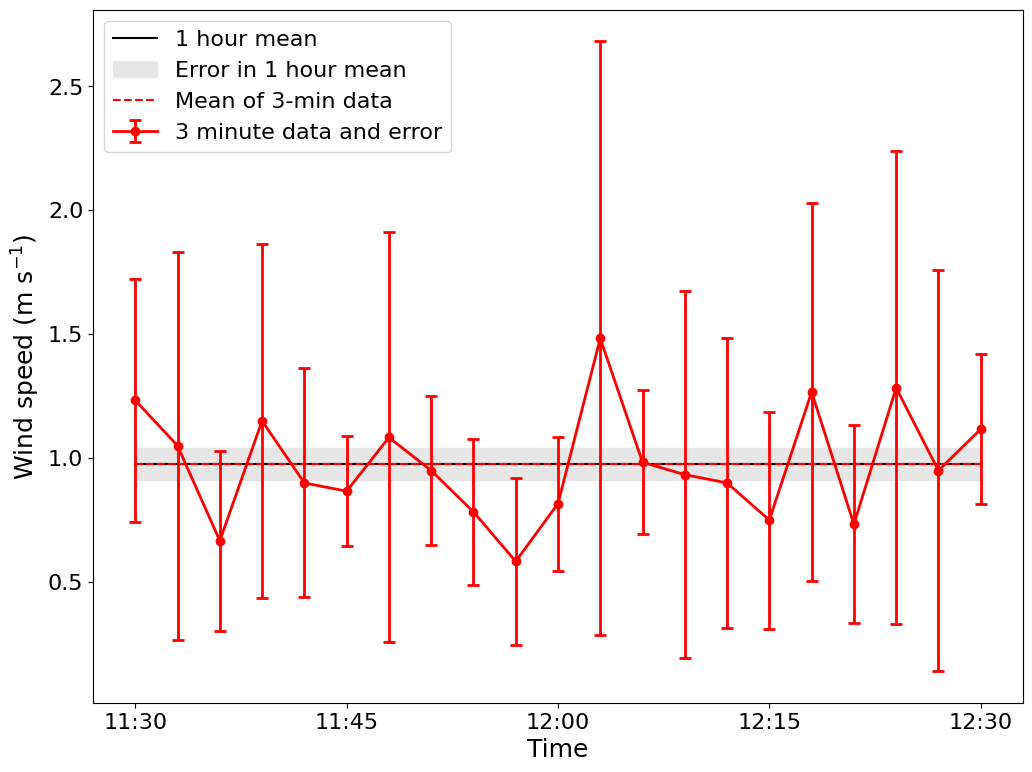

In [257]:
### Wind Plot ###

#Setting up plot 
plt.figure (figsize=(12,9))
fs = 18

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [U_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[U_1h + s_U_1h], 2*[U_1h - s_U_1h], color = '0.9', label = 'Error in 1 hour mean') # Shaded area representing 2 standard errors

# Plotting the 3 minute data with errorbars which represent 2 standard erros 
plt.errorbar(t, U.mean(axis=1), yerr = 2*s_U, marker = 'o', color = 'r', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(U.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
plt.legend(fontsize=fs-2)


plt.ylabel(r'Wind speed ($\mathrm{m}$ $\mathrm{s}^{-1}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)

plt.show()


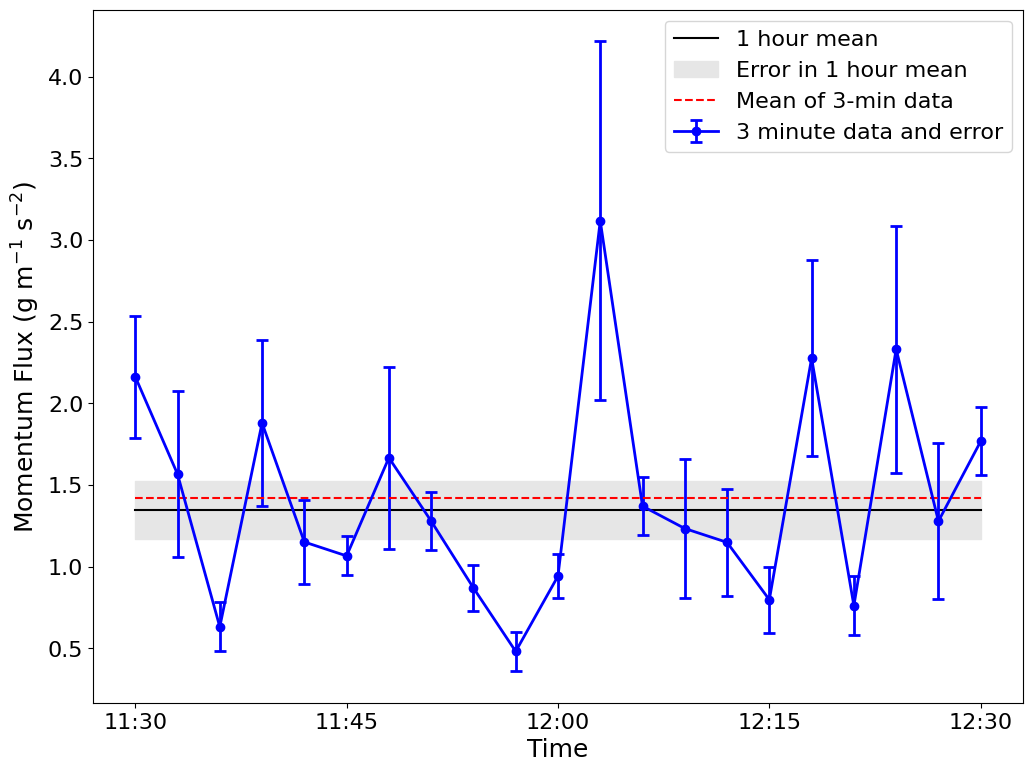

In [258]:
### Momentum Flux Plot ###

#setting up the plot
plt.figure (figsize=(12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with a shaded area which represents 2 standard errors 
plt.plot([11.5, 12.5], 2* [M_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[M_1h + s_M_1h], 2*[M_1h - s_M_1h], color = '0.9', label = 'Error in 1 hour mean') 

#Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, M, yerr = 2*s_M, marker = 'o', color = 'b', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(M.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Momentum Flux ($\mathrm{g}$ $\mathrm{m}^{-1}$ $\mathrm{s}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()

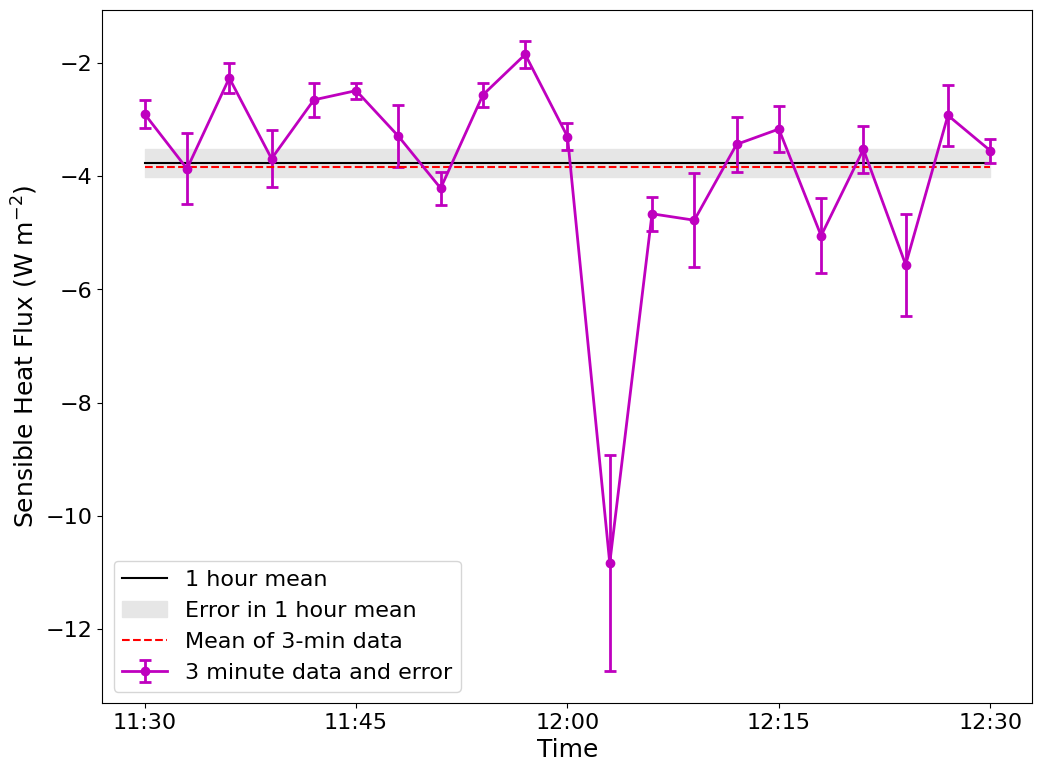

In [259]:
### Sensible Heat Flux Plot ###

# Setting up Figure
fig = plt.figure(figsize = (12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [H_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[H_1h + s_H_1h], 2*[H_1h - s_H_1h], color = '0.9', label = 'Error in 1 hour mean')

# Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, H, yerr = abs(2*s_H), marker = 'o', color = 'm', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(H.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Sensible Heat Flux ($\mathrm{W}$ $\mathrm{m}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()

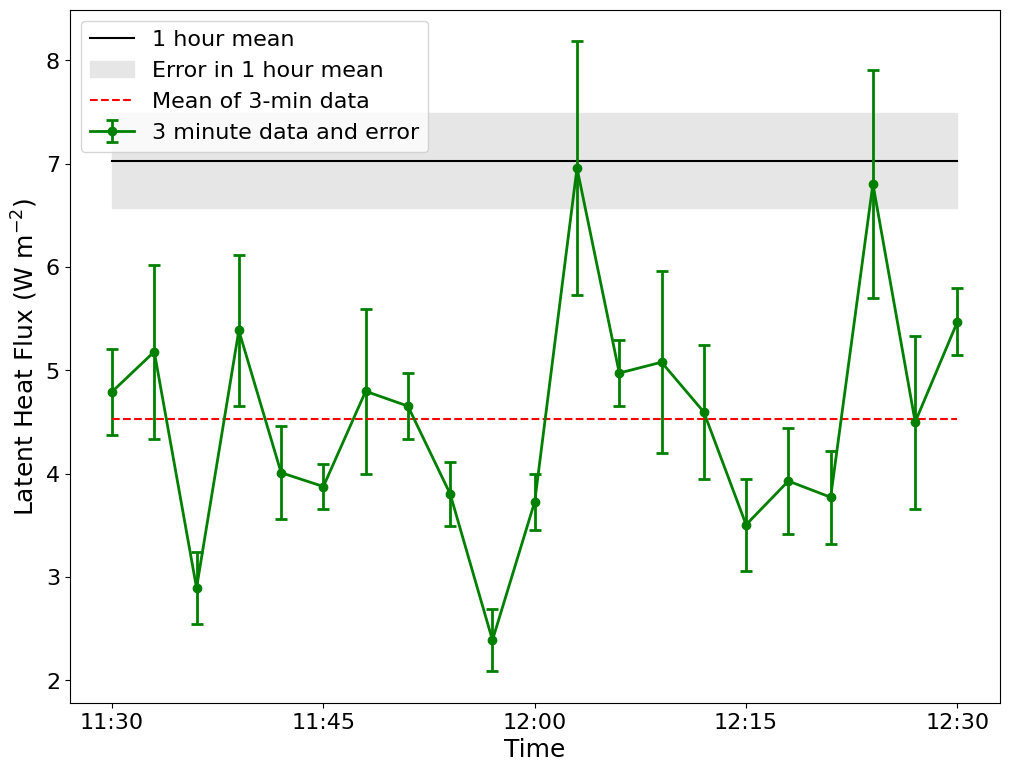

In [261]:
### Latent Heat Flux Plot ### 

# Setting up Figure
fig = plt.figure(figsize = (12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [E_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[E_1h + s_E_1h], 2*[E_1h - s_E_1h], color = '0.9', label = 'Error in 1 hour mean')

# Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, E, yerr = abs(2*s_E), marker = 'o', color = 'g', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(E.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Latent Heat Flux ($\mathrm{W}$ $\mathrm{m}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()